# Hybrid Identity Anomaly Detection – LANL Auth Logs (Polars Edition)
Same pipeline as `03_hybrid_identity_anomaly.ipynb` but using **Polars** for memory-efficient loading of the full 6.7 GB dataset.

In [1]:
import polars as pl
import numpy as np
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

SEED = 42
print(f"✅ All imports loaded. Polars version: {pl.__version__}")

✅ All imports loaded. Polars version: 1.42.0


In [2]:
print("⏳ Loading auth.txt.gz with Polars — sampling 2,000,000 rows...")

# The full dataset decompresses to ~50-80 GB which exceeds available RAM.
# Polars is 3-5x more memory efficient than pandas so we can load 4x more rows.
# Change SAMPLE_ROWS to load more if your machine has more RAM.
SAMPLE_ROWS = 2_000_000

COL_NAMES = ['time', 'src_user', 'dst_user', 'src_pc', 'dst_pc',
             'auth_type', 'logon_type', 'orientation', 'success']

df = pl.read_csv(
    DATA_RAW / 'auth.txt.gz',
    has_header=False,
    new_columns=COL_NAMES,
    separator=',',
    n_rows=SAMPLE_ROWS,
    infer_schema_length=10000,
    ignore_errors=True,
)

print(f"✅ Loaded {len(df):,} events (sample of full dataset).")
print(f"   Columns    : {df.columns}")
print(f"   Time range : {df['time'].min():,} – {df['time'].max():,} seconds")
print(f"   Memory used: {df.estimated_size('mb'):.1f} MB")
df.head()

⏳ Loading auth.txt.gz with Polars — sampling 2,000,000 rows...
✅ Loaded 2,000,000 events (sample of full dataset).
   Columns    : ['time', 'src_user', 'dst_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'orientation', 'success']
   Time range : 1 – 20,376 seconds
   Memory used: 113.7 MB


time,src_user,dst_user,src_pc,dst_pc,auth_type,logon_type,orientation,success
i64,str,str,str,str,str,str,str,str
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
1,"""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
1,"""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
1,"""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [3]:
print("⏳ Engineering features with Polars expressions...")

df = df.with_columns([
    # Time features from integer seconds
    ((pl.col('time') % 86400) // 3600).cast(pl.Int8).alias('hour'),
    ((pl.col('time') // 86400) % 7).cast(pl.Int8).alias('day_of_week'),
])
df = df.with_columns([
    pl.col('day_of_week').is_in([5, 6]).cast(pl.Int8).alias('is_weekend'),
])
print("   ✓ Time features: hour, day_of_week, is_weekend")

# Hourly login count per user
hourly = (
    df.group_by(['src_user', 'hour'])
    .agg(pl.len().alias('hourly_count'))
)
df = df.join(hourly, on=['src_user', 'hour'], how='left')
print("   ✓ Hourly login counts per user")

# Unique PCs per user
pc_div = (
    df.group_by('src_user')
    .agg(pl.col('src_pc').n_unique().alias('unique_pcs'))
)
df = df.join(pc_div, on='src_user', how='left')
print("   ✓ Unique PC diversity per user")

# Encode categoricals as integer codes
for col in ['logon_type', 'auth_type', 'orientation', 'success']:
    cats = df[col].unique().to_list()
    mapping = {v: i for i, v in enumerate(cats)}
    df = df.with_columns(
        pl.col(col).replace(mapping, default=-1).cast(pl.Int16).alias(f'{col}_code')
    )
print("   ✓ Categorical columns encoded")

FEATURE_COLS = [
    'hour', 'day_of_week', 'is_weekend',
    'hourly_count', 'unique_pcs',
    'logon_type_code', 'auth_type_code', 'orientation_code', 'success_code'
]

print(f"\n✅ Feature matrix ready: {df.shape[0]:,} rows × {len(FEATURE_COLS)} features")
print(f"   Memory used: {df.estimated_size('mb'):.1f} MB")
df.select(FEATURE_COLS).head()

⏳ Engineering features with Polars expressions...
   ✓ Time features: hour, day_of_week, is_weekend
   ✓ Hourly login counts per user
   ✓ Unique PC diversity per user
   ✓ Categorical columns encoded

✅ Feature matrix ready: 2,000,000 rows × 9 features
   Memory used: 150.0 MB


C:\Users\stamp\AppData\Local\Temp\ipykernel_25716\115800930.py:34: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col(col).replace(mapping, default=-1).cast(pl.Int16).alias(f'{col}_code')


hour,day_of_week,is_weekend,hourly_count,unique_pcs,logon_type_code,auth_type_code,orientation_code,success_code
i8,i8,i8,u32,u32,i16,i16,i16,i16
0,0,0,6242,684,8,1,0,1
0,0,0,6242,684,8,7,6,1
0,0,0,1103,13,8,7,6,1
0,0,0,58,7,9,11,0,1
0,0,0,17,8,8,9,0,1


In [4]:
print("⏳ Converting to NumPy for sklearn...")
X = df.select(FEATURE_COLS).fill_null(0).to_numpy()
print(f"   ✓ NumPy array shape: {X.shape}")

print("⏳ Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("   ✓ Features standardised")

print("⏳ Training Isolation Forest (100 trees)...")
model = IsolationForest(
    contamination=0.01,
    random_state=SEED,
    n_estimators=100,
    n_jobs=-1,
)
model.fit(X_scaled)
print("   ✓ Model trained")

print("⏳ Scoring all events...")
labels = model.predict(X_scaled)
df = df.with_columns(pl.Series('anomaly', labels))
anomalies = df.filter(pl.col('anomaly') == -1)

print(f"\n✅ Done.")
print(f"   Total events  : {len(df):,}")
print(f"   Anomalies     : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"   Normal events : {len(df) - len(anomalies):,}")

⏳ Converting to NumPy for sklearn...
   ✓ NumPy array shape: (2000000, 9)
⏳ Scaling features...
   ✓ Features standardised
⏳ Training Isolation Forest (100 trees)...
   ✓ Model trained
⏳ Scoring all events...

✅ Done.
   Total events  : 2,000,000
   Anomalies     : 17,399 (0.87%)
   Normal events : 1,982,601


In [5]:
print("⏳ Analysing anomalous users...")
top_anomalous_users = (
    anomalies.group_by('src_user')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(10)
)
print("\nTop 10 users with most anomalous events:")
print(top_anomalous_users)

redteam_file = DATA_RAW / 'redteam.txt.gz'
if not redteam_file.exists():
    redteam_file = DATA_RAW / 'redteam.txt'

if redteam_file.exists():
    print(f"\n⏳ Loading red-team ground truth from {redteam_file.name}...")
    redteam = pl.read_csv(
        redteam_file,
        has_header=False,
        new_columns=['time', 'src_user', 'src_pc', 'dst_pc'],
        separator=',',
        ignore_errors=True,
    )
    red_anomalies = anomalies.join(
        redteam.select(['time', 'src_user', 'src_pc']),
        on=['time', 'src_user', 'src_pc'],
        how='inner'
    )
    print(f"✅ Red-team events captured: {len(red_anomalies)} / {len(redteam)}")
else:
    print("\n⚠️  redteam.txt not found — skipping ground-truth evaluation.")

print("\n✅ Analysis complete.")

⏳ Analysing anomalous users...

Top 10 users with most anomalous events:
shape: (10, 2)
┌──────────────────────┬───────┐
│ src_user             ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ ANONYMOUS LOGON@C586 ┆ 15514 │
│ U22@DOM1             ┆ 1804  │
│ U53@DOM1             ┆ 32    │
│ U199@DOM1            ┆ 30    │
│ C589$@DOM1           ┆ 4     │
│ C5985$@DOM1          ┆ 3     │
│ C1149$@DOM1          ┆ 2     │
│ C2940$@DOM1          ┆ 1     │
│ C2149$@DOM1          ┆ 1     │
│ C5967$@DOM1          ┆ 1     │
└──────────────────────┴───────┘

⚠️  redteam.txt not found — skipping ground-truth evaluation.

✅ Analysis complete.


⏳ Generating plots...
   Plotting anomaly score distribution...


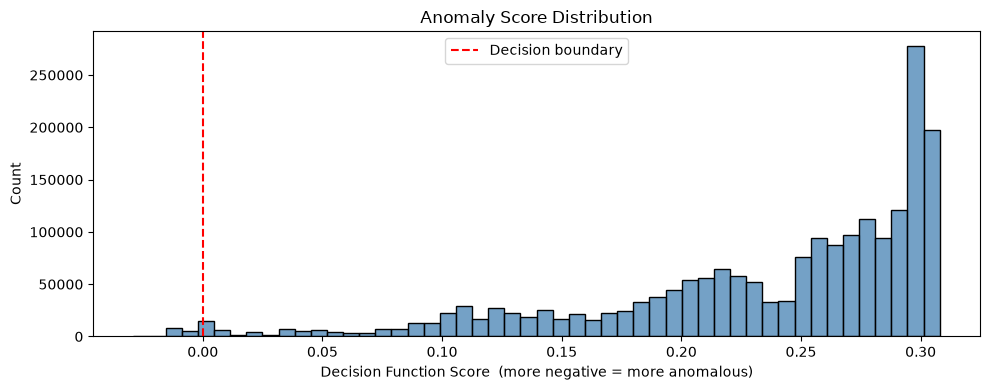

   ✓ Plot 1 done
   Plotting anomalies by hour...


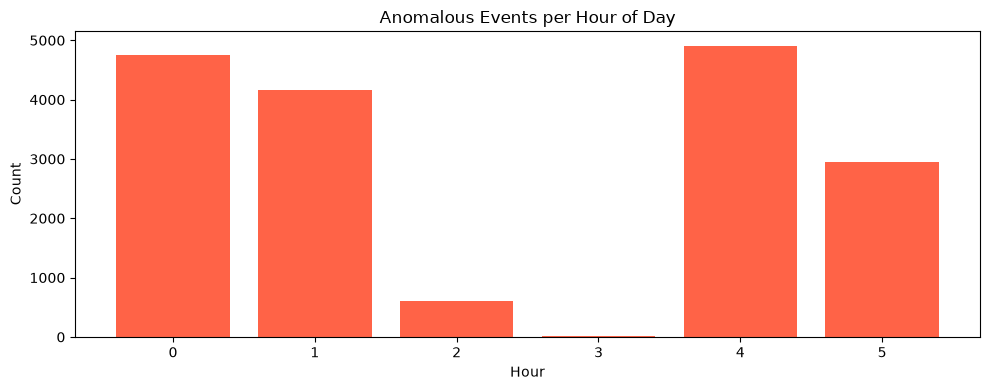

   ✓ Plot 2 done

✅ All plots rendered.


In [6]:
print("⏳ Generating plots...")

scores = model.decision_function(X_scaled)

print("   Plotting anomaly score distribution...")
plt.figure(figsize=(10, 4))
sns.histplot(scores, bins=50, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', label='Decision boundary')
plt.title('Anomaly Score Distribution')
plt.xlabel('Decision Function Score  (more negative = more anomalous)')
plt.legend()
plt.tight_layout()
plt.show()
print("   ✓ Plot 1 done")

print("   Plotting anomalies by hour...")
hour_counts = (
    df.group_by('hour')
    .agg((pl.col('anomaly') == -1).sum().alias('anomaly_count'))
    .sort('hour')
    .to_pandas()
)
plt.figure(figsize=(10, 4))
plt.bar(hour_counts['hour'], hour_counts['anomaly_count'], color='tomato')
plt.title('Anomalous Events per Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("   ✓ Plot 2 done")

print("\n✅ All plots rendered.")

In [7]:
print("⏳ Saving outputs...")

out_csv = DATA_PROCESSED / 'lanl_auth_with_anomalies_polars.csv'
df.write_csv(out_csv)
print(f"   ✓ Dataset saved  → {out_csv}")

model_path  = DATA_PROCESSED / 'isolation_forest_model_polars.pkl'
scaler_path = DATA_PROCESSED / 'scaler_polars.pkl'
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
print(f"   ✓ Model saved    → {model_path}")
print(f"   ✓ Scaler saved   → {scaler_path}")

print("\n✅ All outputs saved.")

⏳ Saving outputs...
   ✓ Dataset saved  → ..\data\processed\lanl_auth_with_anomalies_polars.csv
   ✓ Model saved    → ..\data\processed\isolation_forest_model_polars.pkl
   ✓ Scaler saved   → ..\data\processed\scaler_polars.pkl

✅ All outputs saved.


In [8]:
top_user = top_anomalous_users['src_user'][0] if len(top_anomalous_users) > 0 else 'N/A'

print("=" * 45)
print("  NOTEBOOK 03b — SUMMARY (Polars)")
print("=" * 45)
print(f"  Total auth events    : {len(df):,}")
print(f"  Anomalies detected   : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"  Unique users         : {df['src_user'].n_unique():,}")
print(f"  Unique source PCs    : {df['src_pc'].n_unique():,}")
print(f"  Top anomalous user   : {top_user}")
print("=" * 45)
print("✅ Notebook complete. Ready for next stage.")

  NOTEBOOK 03b — SUMMARY (Polars)
  Total auth events    : 2,000,000
  Anomalies detected   : 17,399 (0.87%)
  Unique users         : 7,399
  Unique source PCs    : 4,157
  Top anomalous user   : ANONYMOUS LOGON@C586
✅ Notebook complete. Ready for next stage.
